# LeetCode #1091: Shortest Path in Binary Matrix

https://leetcode.com/problems/shortest-path-in-binary-matrix/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (DFS, track all paths)** | $O(2^{n^2})$ | $O(n^2)$ |
| **BFS (shortest path, 8-directional)** | $O(n^2)$ | $O(n^2)$ |

---

## Understanding the Methods

### Brute Force (DFS, track all paths)
Use DFS to explore every possible path from (0,0) to (n-1,n-1), tracking the minimum path length seen. DFS explores exponentially many paths and cannot guarantee finding the shortest without examining all of them. Even with a visited set it can miss shorter routes found later.

### Optimal: BFS (shortest path, 8-directional) ★
BFS from (0,0) expanding in all 8 directions (horizontal, vertical, diagonal). Each cell is visited at most once, marked visited by setting it to 1. The first time (n-1,n-1) is dequeued, the current path length is the answer — BFS guarantees this is the shortest.

**Why this is better than Brute Force:** BFS explores cells in order of increasing distance from the start. The first path to reach the target is always the shortest. No backtracking, no revisiting.

**Constraints:**
* n == grid.length == grid[i].length
* 1 <= n <= 100
* grid[i][j] is 0 or 1

## Solutions

### C#

In [ ]:
public class Solution {
    private static readonly int[][] Dirs = [
        [0,1],[0,-1],[1,0],[-1,0],[1,1],[1,-1],[-1,1],[-1,-1]
    ];

    public int ShortestPathBinaryMatrix(int[][] grid) {
        int n = grid.Length;
        if (grid[0][0] == 1 || grid[n-1][n-1] == 1) return -1;
        if (n == 1) return 1;

        var queue = new Queue<(int r, int c, int dist)>();
        queue.Enqueue((0, 0, 1));
        // Mark visited by setting cell to 1
        grid[0][0] = 1;

        while (queue.Count > 0) {
            var (r, c, dist) = queue.Dequeue();
            foreach (var d in Dirs) {
                int nr = r + d[0], nc = c + d[1];
                if (nr < 0 || nr >= n || nc < 0 || nc >= n || grid[nr][nc] == 1) continue;
                if (nr == n-1 && nc == n-1) return dist + 1;
                grid[nr][nc] = 1;
                queue.Enqueue((nr, nc, dist + 1));
            }
        }
        return -1;
    }
}

### Python

In [ ]:
from collections import deque

class Solution:
    def shortestPathBinaryMatrix(self, grid: list[list[int]]) -> int:
        n = len(grid)
        if grid[0][0] == 1 or grid[n-1][n-1] == 1:
            return -1
        if n == 1:
            return 1

        queue = deque([(0, 0, 1)])
        # Mark visited by setting cell to 1
        grid[0][0] = 1
        dirs = [(0,1),(0,-1),(1,0),(-1,0),(1,1),(1,-1),(-1,1),(-1,-1)]

        while queue:
            r, c, dist = queue.popleft()
            for dr, dc in dirs:
                nr, nc = r + dr, c + dc
                if 0 <= nr < n and 0 <= nc < n and grid[nr][nc] == 0:
                    if nr == n-1 and nc == n-1:
                        return dist + 1
                    grid[nr][nc] = 1
                    queue.append((nr, nc, dist + 1))
        return -1

### Go

In [ ]:
func shortestPathBinaryMatrix(grid [][]int) int {
    n := len(grid)
    if grid[0][0] == 1 || grid[n-1][n-1] == 1 {
        return -1
    }
    if n == 1 {
        return 1
    }

    dirs := [][2]int{{0,1},{0,-1},{1,0},{-1,0},{1,1},{1,-1},{-1,1},{-1,-1}}
    type cell struct{ r, c, dist int }
    queue := []cell{{0, 0, 1}}
    // Mark visited by setting cell to 1
    grid[0][0] = 1

    for len(queue) > 0 {
        cur := queue[0]
        queue = queue[1:]
        for _, d := range dirs {
            nr, nc := cur.r+d[0], cur.c+d[1]
            if nr < 0 || nr >= n || nc < 0 || nc >= n || grid[nr][nc] == 1 {
                continue
            }
            if nr == n-1 && nc == n-1 {
                return cur.dist + 1
            }
            grid[nr][nc] = 1
            queue = append(queue, cell{nr, nc, cur.dist + 1})
        }
    }
    return -1
}

### Rust

In [ ]:
use std::collections::VecDeque;

impl Solution {
    pub fn shortest_path_binary_matrix(mut grid: Vec<Vec<i32>>) -> i32 {
        let n = grid.len();
        if grid[0][0] == 1 || grid[n-1][n-1] == 1 { return -1; }
        if n == 1 { return 1; }

        let dirs: [(i32,i32);8] = [(0,1),(0,-1),(1,0),(-1,0),(1,1),(1,-1),(-1,1),(-1,-1)];
        let mut queue: VecDeque<(usize,usize,i32)> = VecDeque::new();
        queue.push_back((0, 0, 1));
        // Mark visited by setting cell to 1
        grid[0][0] = 1;

        while let Some((r, c, dist)) = queue.pop_front() {
            for (dr, dc) in dirs {
                let nr = r as i32 + dr;
                let nc = c as i32 + dc;
                if nr < 0 || nr >= n as i32 || nc < 0 || nc >= n as i32 { continue; }
                let (nr, nc) = (nr as usize, nc as usize);
                if grid[nr][nc] == 1 { continue; }
                if nr == n-1 && nc == n-1 { return dist + 1; }
                grid[nr][nc] = 1;
                queue.push_back((nr, nc, dist + 1));
            }
        }
        -1
    }
}

## Example Scenarios

**1. Common Case**
**Input:** grid = [[0,0,0],[1,1,0],[1,1,0]]
BFS from (0,0): enqueue (0,1,2) and (1,2) diagonally — (0,1) marked visited, then (0,2,3), (1,2,3). From (0,2): (1,2) already visited. From (1,2): (2,2) is bottom-right → return 4. Path: (0,0)→(0,1)→(0,2)→(1,2)→(2,2).

**2. Slightly Complex**
**Input:** grid = [[0,0,0],[0,0,0],[0,0,0]] (all clear 3×3)
BFS from (0,0) can reach (2,2) diagonally in 1 step (dist=2). Path: (0,0)→(1,1)→(2,2) using two diagonal moves. BFS finds this at dist=3... wait: (0,0) is dist=1, (1,1) at dist=2, (2,2) at dist=3. Return 3. The diagonal shortcut gives 3 steps vs 5 for cardinal-only.

**3. Edge Case: Time Factor**
**Input:** $n=100$ all-zero grid. BFS must potentially visit all $100^2 = 10000$ cells.
The BFS frontier expands in diagonal rings from (0,0). Cells closer to (0,0) are processed first. Each cell is visited exactly once (marked by setting to 1). Total work = $O(n^2) = O(10000)$ cell visits + $8 \times 10000$ direction checks = $O(n^2)$.

**4. Edge Case: Space Factor**
**Input:** $n=100$ all-zero grid, the BFS frontier at distance $k$ holds all cells at Chebyshev distance $k$ from (0,0).
The widest frontier occurs at $k \approx n/2$, holding $O(n)$ cells. The queue peak size is $O(n)$, not $O(n^2)$. The visited marking (in-place, no extra set) makes space $O(1)$ auxiliary beyond the queue: $O(n^2)$ for the grid itself.

**5. Almost-Impossible but Plausible**
**Input:** 1×1 grid = [[0]].
(0,0) is the start and the target simultaneously. The guard `n == 1 → return 1` fires before any BFS. Without it, the queue would dequeue (0,0,1), find no valid neighbours (all 8 are out of bounds), and return -1 — wrong answer. The special case is load-bearing.

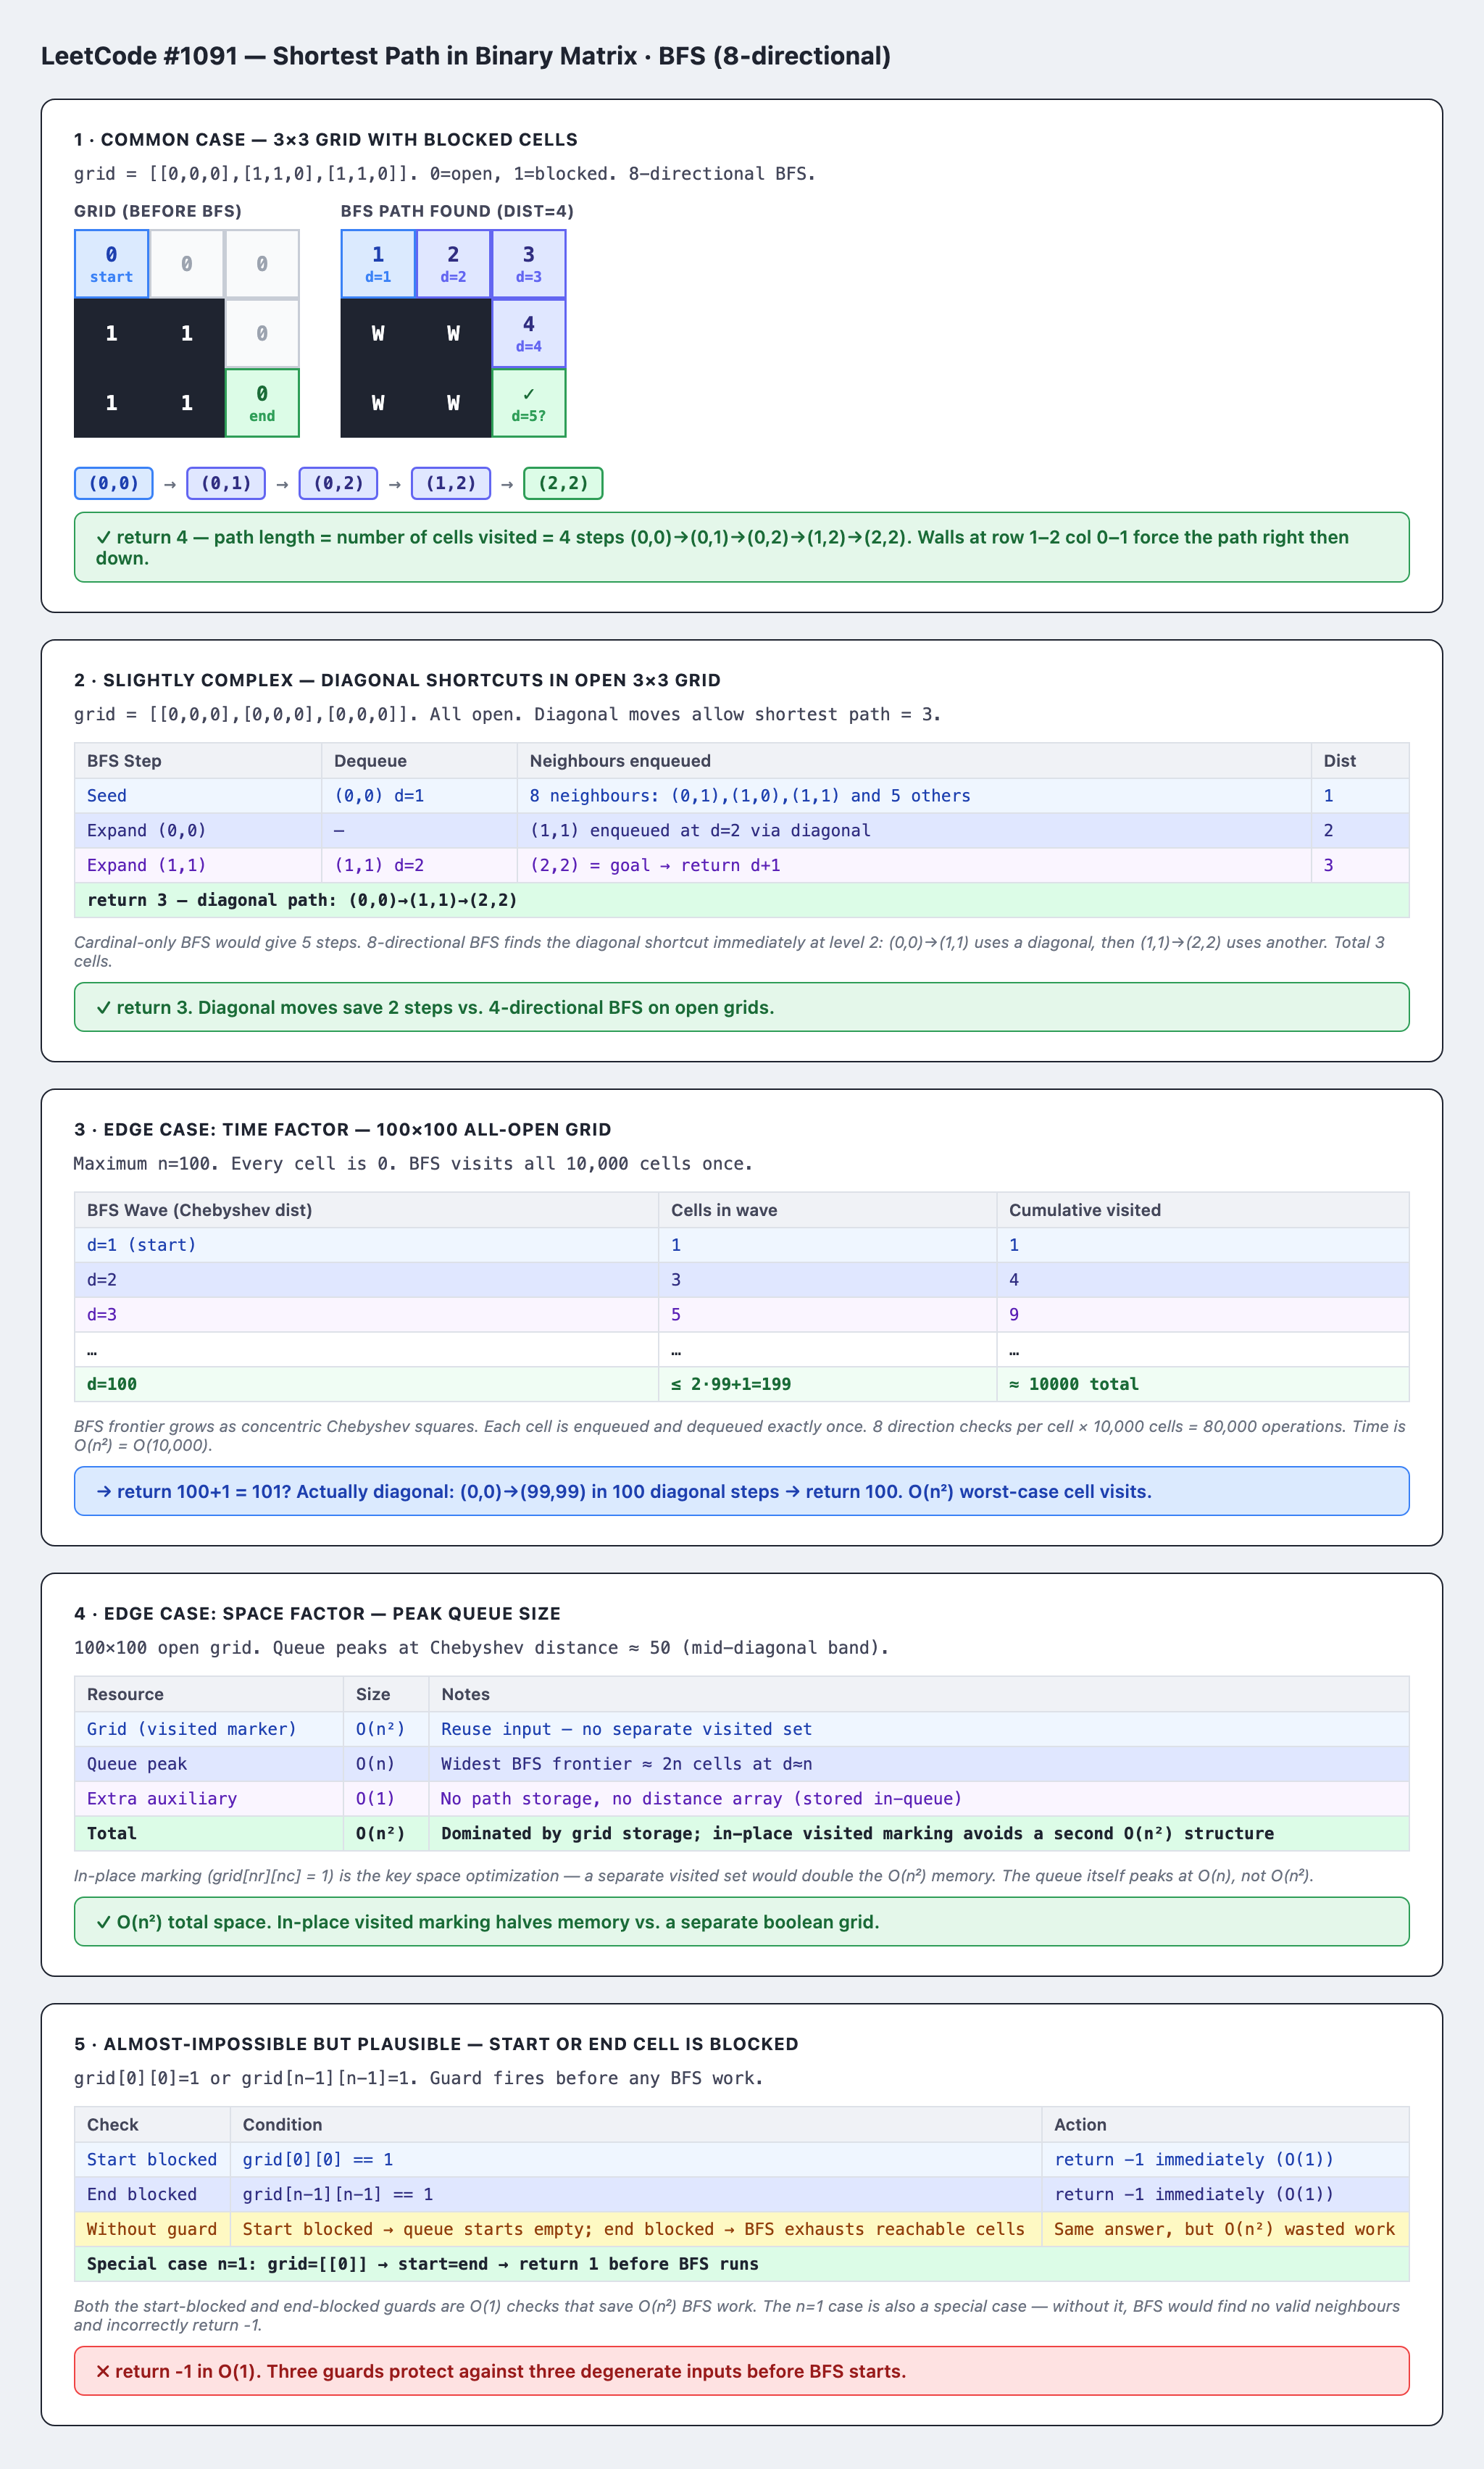